In [25]:
import sys, os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thư viện cho Time Series
from statsmodels.tsa.seasonal import seasonal_decompose

# Set random state and plot style
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Add src to path
sys.path.append(os.path.abspath(os.path.join("..", "src")))
from data_loader import DataLoader

In [26]:
# ============================================================
# CELL 1: Setup & Load Data
# ============================================================
print("=== CELL 1: Setup & Load Data ===")
loader = DataLoader()

# Load necessary tables
sales = loader.load("sales")

print("Sales data shape:", sales.shape)
print("Date range:", sales['Date'].min(), "to", sales['Date'].max())
print(sales.head(3))

=== CELL 1: Setup & Load Data ===
Sales data shape: (3833, 3)
Date range: 2012-07-04 to 2022-12-31
shape: (3, 3)
┌────────────┬──────────┬──────────┐
│ Date       ┆ Revenue  ┆ COGS     │
│ ---        ┆ ---      ┆ ---      │
│ date       ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╡
│ 2012-07-04 ┆ 5.1235e6 ┆ 3.9830e6 │
│ 2012-07-05 ┆ 2.7518e6 ┆ 2.1506e6 │
│ 2012-07-06 ┆ 3.0540e6 ┆ 2.5176e6 │
└────────────┴──────────┴──────────┘


In [27]:
# ============================================================
# CELL 2: DQA - Check Nulls & Logical Errors
# ============================================================
print("\n=== CELL 2: DQA - Null & Logical Checks ===")
# 1. Check Nulls
null_counts = sales.null_count()
print("Null Counts:")
print(null_counts)

# 2. Xử lý Logical Errors (Revenue hoặc COGS <= 0)
invalid_rows = sales.filter((pl.col("Revenue") <= 0) | (pl.col("COGS") <= 0))
if invalid_rows.height > 0:
    print(f"⚠️ Phát hiện {invalid_rows.height} dòng có Revenue hoặc COGS <= 0. Tiến hành lọc bỏ...")
    sales = sales.filter((pl.col("Revenue") > 0) & (pl.col("COGS") > 0))
else:
    print("✅ Không có dòng dữ liệu Revenue/COGS <= 0.")

# 3. Thêm các cột thời gian cần thiết
sales = sales.with_columns([
    pl.col("Date").dt.year().alias("Year"),
    pl.col("Date").dt.month().alias("Month"),
    pl.col("Date").dt.quarter().alias("Quarter"),
    pl.col("Date").dt.strftime("%Y-%m").alias("YearMonth")
])




=== CELL 2: DQA - Null & Logical Checks ===
Null Counts:
shape: (1, 3)
┌──────┬─────────┬──────┐
│ Date ┆ Revenue ┆ COGS │
│ ---  ┆ ---     ┆ ---  │
│ u32  ┆ u32     ┆ u32  │
╞══════╪═════════╪══════╡
│ 0    ┆ 0       ┆ 0    │
└──────┴─────────┴──────┘
✅ Không có dòng dữ liệu Revenue/COGS <= 0.


In [28]:
# ============================================================
# CELL 3: DQA - Outlier Detection (IQR Method)
# ============================================================
print("\n=== CELL 3: DQA - Outlier Detection ===")
def remove_outliers_iqr(df, col_name, multiplier=1.5):
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr
    
    # Gom các dòng Outliers
    outliers = df.filter((pl.col(col_name) < lower_bound) | (pl.col(col_name) > upper_bound))
    print(f"Cột {col_name}: Phát hiện {outliers.height} outliers (ngưỡng {multiplier} IQR).")
    
    # Data sạch
    df_clean = df.filter((pl.col(col_name) >= lower_bound) & (pl.col(col_name) <= upper_bound))
    return df_clean, outliers

# Lọc Outliers và lưu nhóm Outliers ra riêng để phân tích
original_height = sales.height
sales, rev_outliers = remove_outliers_iqr(sales, "Revenue", 3.0)
sales, cogs_outliers = remove_outliers_iqr(sales, "COGS", 3.0)

# Gộp chung toàn bộ Outliers của cả Revenue và COGS lại thành 1 bảng duy nhất
sales_outliers = pl.concat([rev_outliers, cogs_outliers])

print(f"Đã loại bỏ tổng cộng {original_height - sales.height} dòng cực đoan.")
print(f"Tổng số Outliers gom được để Deep Dive: {sales_outliers.height} dòng.")


=== CELL 3: DQA - Outlier Detection ===
Cột Revenue: Phát hiện 34 outliers (ngưỡng 3.0 IQR).
Cột COGS: Phát hiện 5 outliers (ngưỡng 3.0 IQR).
Đã loại bỏ tổng cộng 39 dòng cực đoan.
Tổng số Outliers gom được để Deep Dive: 39 dòng.


# INSIGHT:
# >> "Đã làm sạch dữ liệu: Không có Null, loại bỏ các đơn hàng doanh thu âm, và lọc các Outliers cực đoan để biểu đồ phản ánh đúng xu hướng thực tế."

In [29]:
# Thêm cột Year và Month
sales = sales.with_columns([
    pl.col("Date").dt.year().alias("Year"),
    pl.col("Date").dt.month().alias("Month"),
    pl.col("Date").dt.quarter().alias("Quarter")
])

# Group by Year
yearly_sales = sales.group_by("Year").agg(
    pl.col("Revenue").sum().alias("Total_Revenue")
).sort("Year")

# Tính Growth Rate
yearly_sales = yearly_sales.with_columns([
    (pl.col("Total_Revenue").diff() / pl.col("Total_Revenue").shift(1) * 100).alias("YoY_Growth_Rate_%")
])

print(yearly_sales)

shape: (11, 3)
┌──────┬───────────────┬───────────────────┐
│ Year ┆ Total_Revenue ┆ YoY_Growth_Rate_% │
│ ---  ┆ ---           ┆ ---               │
│ i32  ┆ f64           ┆ f64               │
╞══════╪═══════════════╪═══════════════════╡
│ 2012 ┆ 7.4150e8      ┆ null              │
│ 2013 ┆ 1.6462e9      ┆ 122.006232        │
│ 2014 ┆ 1.8403e9      ┆ 11.790405         │
│ 2015 ┆ 1.7882e9      ┆ -2.828661         │
│ 2016 ┆ 1.8929e9      ┆ 5.854692          │
│ 2017 ┆ 1.7487e9      ┆ -7.616489         │
│ 2018 ┆ 1.7607e9      ┆ 0.682825          │
│ 2019 ┆ 1.1368e9      ┆ -35.433547        │
│ 2020 ┆ 1.0545e9      ┆ -7.238668         │
│ 2021 ┆ 1.0430e9      ┆ -1.087929         │
│ 2022 ┆ 1.1697e9      ┆ 12.148051         │
└──────┴───────────────┴───────────────────┘


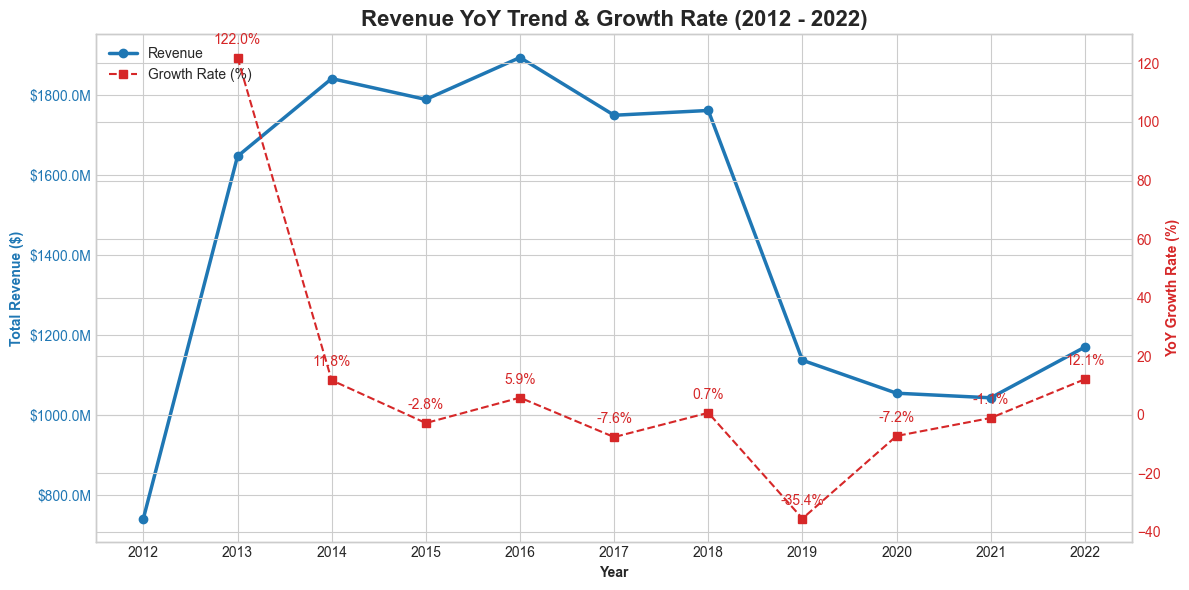

In [30]:
# Vẽ Line Chart YoY
fig, ax1 = plt.subplots(figsize=(12, 6))

years = yearly_sales["Year"].to_list()
revenue = yearly_sales["Total_Revenue"].to_list()
growth = yearly_sales["YoY_Growth_Rate_%"].to_list()

color = 'tab:blue'
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Total Revenue ($)', color=color, fontweight='bold')
line1 = ax1.plot(years, revenue, marker='o', linewidth=2.5, color=color, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(years)

# Format y-axis to millions
formatter = plt.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M')
ax1.yaxis.set_major_formatter(formatter)

# Dual axis for Growth Rate
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('YoY Growth Rate (%)', color=color2, fontweight='bold')
line2 = ax2.plot(years, growth, marker='s', linestyle='--', color=color2, label='Growth Rate (%)')
ax2.tick_params(axis='y', labelcolor=color2)

# Annotate anomalies/key points
for i, txt in enumerate(growth):
    if txt is not None and not np.isnan(txt):
        ax2.annotate(f"{txt:.1f}%", (years[i], growth[i]), textcoords="offset points", xytext=(0,10), ha='center', color=color2)

plt.title('Revenue YoY Trend & Growth Rate (2012 - 2022)', fontsize=16, fontweight='bold')
fig.tight_layout()

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.show()

In [31]:
# ============================================================
# CELL 4: Financial Health - Gross Profit & Margin
# ============================================================
print("\n=== CELL 4: Gross Profit & Margin Calculation ===")
# Tạo cột Gross Profit và Gross Margin
sales = sales.with_columns([
    (pl.col("Revenue") - pl.col("COGS")).alias("Gross_Profit")
])

sales = sales.with_columns([
    (pl.col("Gross_Profit") / pl.col("Revenue") * 100).alias("Gross_Margin_%")
])

print(sales.select(["Date", "Revenue", "COGS", "Gross_Profit", "Gross_Margin_%"]))




=== CELL 4: Gross Profit & Margin Calculation ===
shape: (3_794, 5)
┌────────────┬───────────┬────────────┬──────────────┬────────────────┐
│ Date       ┆ Revenue   ┆ COGS       ┆ Gross_Profit ┆ Gross_Margin_% │
│ ---        ┆ ---       ┆ ---        ┆ ---          ┆ ---            │
│ date       ┆ f64       ┆ f64        ┆ f64          ┆ f64            │
╞════════════╪═══════════╪════════════╪══════════════╪════════════════╡
│ 2012-07-04 ┆ 5.1235e6  ┆ 3.9830e6   ┆ 1.1406e6     ┆ 22.261073      │
│ 2012-07-05 ┆ 2.7518e6  ┆ 2.1506e6   ┆ 601193.22    ┆ 21.847482      │
│ 2012-07-06 ┆ 3.0540e6  ┆ 2.5176e6   ┆ 536396.58    ┆ 17.56357       │
│ 2012-07-07 ┆ 2.6679e6  ┆ 2.1082e6   ┆ 559684.32    ┆ 20.978216      │
│ 2012-07-08 ┆ 2360851.9 ┆ 1.8086e6   ┆ 552229.11    ┆ 23.391095      │
│ 2012-07-09 ┆ 3.5484e6  ┆ 2.7878e6   ┆ 760544.78    ┆ 21.433539      │
│ 2012-07-10 ┆ 5.2349e6  ┆ 4.0444e6   ┆ 1.1905e6     ┆ 22.741428      │
│ 2012-07-11 ┆ 5.5829e6  ┆ 4.3383e6   ┆ 1.2446e6     ┆ 22.292628   


=== CELL 5: YoY Growth & CAGR ===
shape: (10, 5)
┌──────┬───────────────┬────────────────────┬───────────────────┬────────────────────┐
│ Year ┆ Total_Revenue ┆ Total_Gross_Profit ┆ YoY_Growth_Rate_% ┆ Avg_Gross_Margin_% │
│ ---  ┆ ---           ┆ ---                ┆ ---               ┆ ---                │
│ i32  ┆ f64           ┆ f64                ┆ f64               ┆ f64                │
╞══════╪═══════════════╪════════════════════╪═══════════════════╪════════════════════╡
│ 2013 ┆ 1.6462e9      ┆ 1.9236e8           ┆ null              ┆ 11.685195          │
│ 2014 ┆ 1.8403e9      ┆ 2.9068e8           ┆ 11.790405         ┆ 15.79574           │
│ 2015 ┆ 1.7882e9      ┆ 2.0852e8           ┆ -2.828661         ┆ 11.661108          │
│ 2016 ┆ 1.8929e9      ┆ 2.9017e8           ┆ 5.854692          ┆ 15.329307          │
│ 2017 ┆ 1.7487e9      ┆ 1.9488e8           ┆ -7.616489         ┆ 11.144004          │
│ 2018 ┆ 1.7607e9      ┆ 2.9153e8           ┆ 0.682825          ┆ 16.557985     

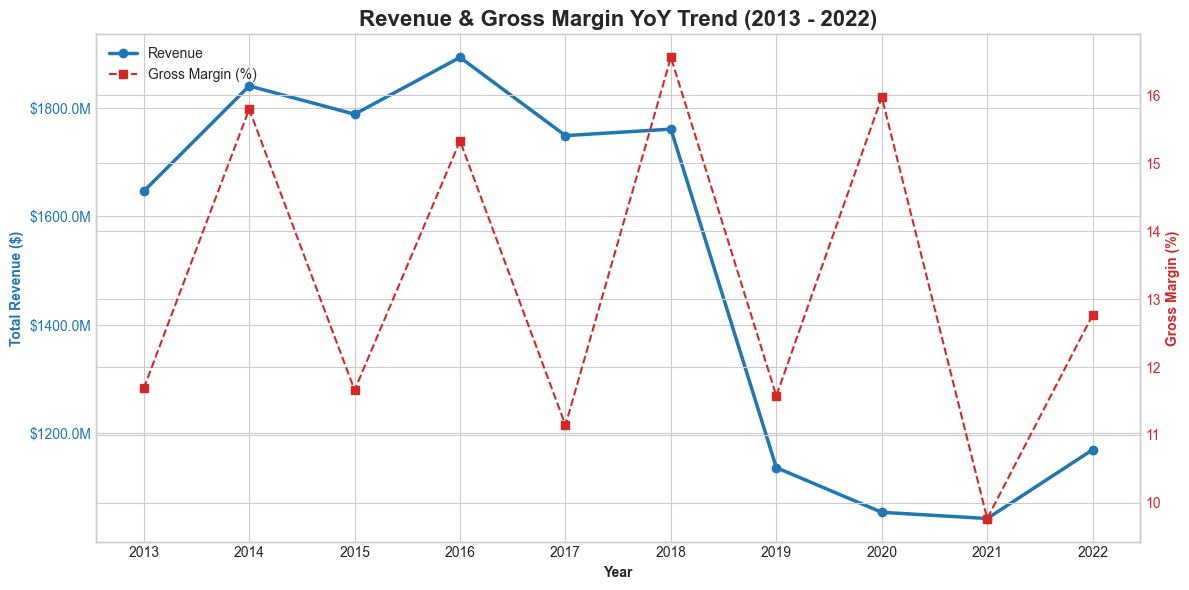

In [32]:

# ============================================================
# CELL 5: Revenue YoY Trend & CAGR (Full Years Only)
# ============================================================
print("\n=== CELL 5: YoY Growth & CAGR ===")
# Loại bỏ năm 2012 (năm khuyết) để tính YoY và CAGR cho chuẩn xác
sales_full_years = sales.filter(pl.col("Year") >= 2013)

yearly_sales = sales_full_years.group_by("Year").agg(
    pl.col("Revenue").sum().alias("Total_Revenue"),
    pl.col("Gross_Profit").sum().alias("Total_Gross_Profit")
).sort("Year")

yearly_sales = yearly_sales.with_columns([
    (pl.col("Total_Revenue").diff() / pl.col("Total_Revenue").shift(1) * 100).alias("YoY_Growth_Rate_%"),
    (pl.col("Total_Gross_Profit") / pl.col("Total_Revenue") * 100).alias("Avg_Gross_Margin_%")
])

print(yearly_sales)

# Tính CAGR (2013-2022)
start_year = 2013
end_year = yearly_sales["Year"][-1]
num_years = end_year - start_year

start_revenue = yearly_sales.filter(pl.col("Year") == start_year)["Total_Revenue"][0]
end_revenue = yearly_sales.filter(pl.col("Year") == end_year)["Total_Revenue"][0]

cagr = ((end_revenue / start_revenue) ** (1 / num_years)) - 1
print(f"\nCAGR ({start_year}-{end_year}): {cagr * 100:.2f}%")

# Vẽ biểu đồ kép: Revenue vs Gross Margin
fig, ax1 = plt.subplots(figsize=(12, 6))
years = yearly_sales["Year"].to_list()
revenue = yearly_sales["Total_Revenue"].to_list()
margin = yearly_sales["Avg_Gross_Margin_%"].to_list()

color = 'tab:blue'
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Total Revenue ($)', color=color, fontweight='bold')
line1 = ax1.plot(years, revenue, marker='o', linewidth=2.5, color=color, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(years)

formatter = plt.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M')
ax1.yaxis.set_major_formatter(formatter)

ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('Gross Margin (%)', color=color2, fontweight='bold')
line2 = ax2.plot(years, margin, marker='s', linestyle='--', color=color2, label='Gross Margin (%)')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Revenue & Gross Margin YoY Trend (2013 - 2022)', fontsize=16, fontweight='bold')
fig.tight_layout()

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.savefig(os.path.join(FIGURES_DIR, "day2_revenue_margin_yoy.png"), bbox_inches="tight")
plt.show()


# INSIGHT:
# >> "CAGR đạt ...%. Dù doanh thu (Revenue) có xu hướng tăng, nhưng Biên lợi nhuận gộp (Gross Margin) có đang được duy trì ổn định hay không? Nếu Biên giảm, có nghĩa chi phí giá vốn (COGS) đang ăn mòn lợi nhuận."



=== CELL 6: QoQ Growth Trend ===


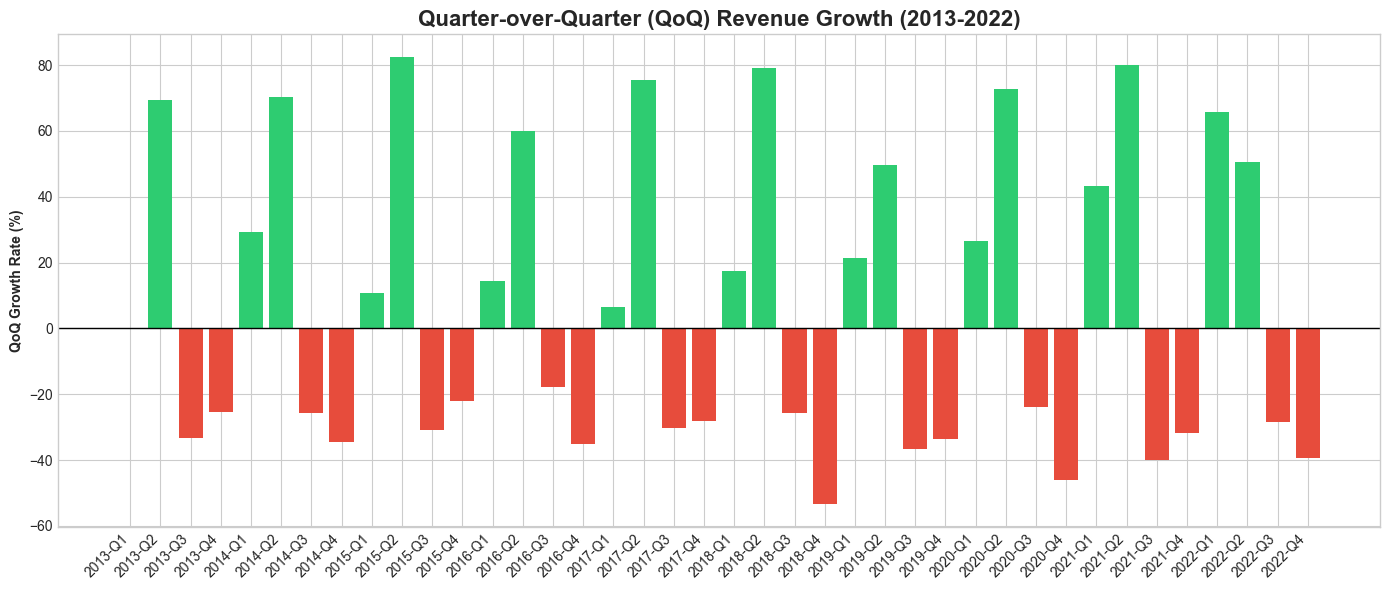

In [33]:
# ============================================================
# CELL 6: QoQ Trend (Quarter over Quarter)
# ============================================================
print("\n=== CELL 6: QoQ Growth Trend ===")
sales = sales.with_columns([
    (pl.col("Year").cast(pl.String) + "-Q" + pl.col("Quarter").cast(pl.String)).alias("YearQuarter")
])

quarterly_sales = sales_full_years.group_by(["Year", "Quarter"]).agg(
    pl.col("Revenue").sum().alias("Total_Revenue")
).sort(["Year", "Quarter"])

quarterly_sales = quarterly_sales.with_columns([
    (pl.col("Year").cast(pl.String) + "-Q" + pl.col("Quarter").cast(pl.String)).alias("YearQuarter"),
    (pl.col("Total_Revenue").diff() / pl.col("Total_Revenue").shift(1) * 100).alias("QoQ_Growth_Rate_%")
])

# Plot QoQ Growth
plt.figure(figsize=(14, 6))
q_labels = quarterly_sales["YearQuarter"].to_list()
q_growth = quarterly_sales["QoQ_Growth_Rate_%"].fill_null(0).to_list()

plt.bar(q_labels, q_growth, color=np.where(np.array(q_growth) > 0, '#2ecc71', '#e74c3c'))
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('QoQ Growth Rate (%)', fontweight='bold')
plt.title('Quarter-over-Quarter (QoQ) Revenue Growth (2013-2022)', fontweight='bold', fontsize=16)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day2_qoq_growth.png"), bbox_inches="tight")
plt.show()


# INSIGHT:
# >> "Nhìn vào QoQ, chúng ta thấy rõ những nhịp gãy (Quý nào thường bị sụt giảm mạnh) và nhịp phục hồi. Q4 thường có mức phục hồi rất tốt sau điểm trũng của Q3."



=== CELL 7: Monthly Rolling Average ===


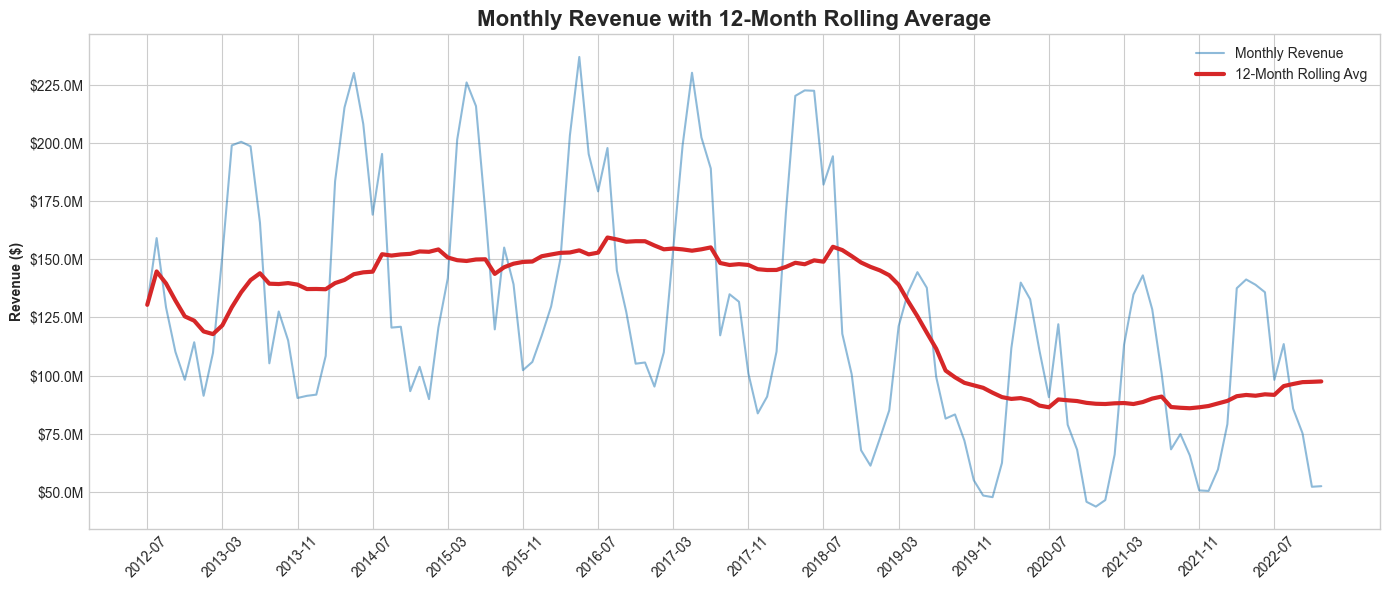

In [34]:
# ============================================================
# CELL 7: Monthly Seasonality & 12-Month Rolling Average
# ============================================================
print("\n=== CELL 7: Monthly Rolling Average ===")
monthly_sales = sales.group_by("YearMonth").agg(
    pl.col("Revenue").sum().alias("Total_Revenue")
).sort("YearMonth")

# Chuyển sang Pandas để dùng hàm rolling dễ dàng hơn
monthly_pd = monthly_sales.to_pandas()
monthly_pd['12M_Rolling_Avg'] = monthly_pd['Total_Revenue'].rolling(window=12, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_pd['YearMonth'], monthly_pd['Total_Revenue'], alpha=0.5, label='Monthly Revenue', color='tab:blue')
plt.plot(monthly_pd['YearMonth'], monthly_pd['12M_Rolling_Avg'], linewidth=3, label='12-Month Rolling Avg', color='tab:red')

# Rút gọn nhãn trục X cho đỡ rối
step = len(monthly_pd) // 15
plt.xticks(monthly_pd['YearMonth'][::step], rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M'))
plt.ylabel('Revenue ($)', fontweight='bold')
plt.title('Monthly Revenue with 12-Month Rolling Average', fontweight='bold', fontsize=16)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day2_monthly_rolling.png"), bbox_inches="tight")
plt.show()

# INSIGHT:
# >> "Đường Rolling Average làm mượt (smooth) biểu đồ, cho thấy rõ ràng chu kỳ vĩ mô: Giai đoạn đi ngang 2014-2015, suy thoái 2019-2021 và sự phục hồi vào cuối 2022."



=== CELL 8: Time-Series Decomposition ===


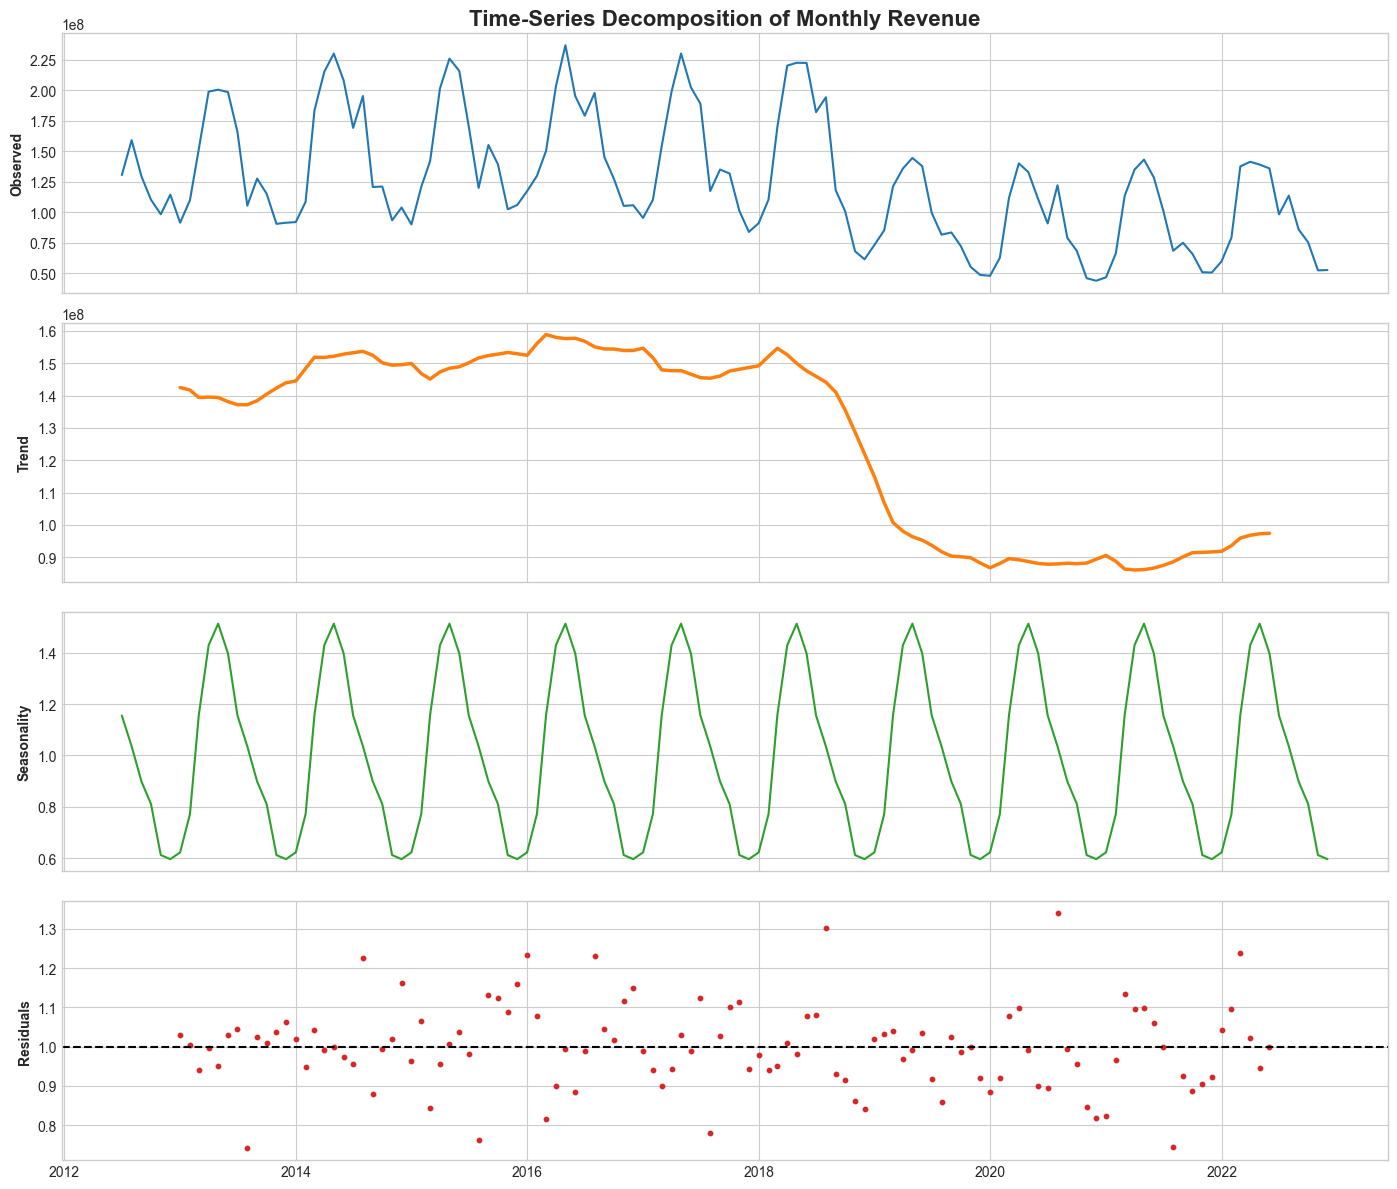

In [35]:
# ============================================================
# CELL 8: Time-Series Decomposition (Advanced)
# ============================================================
print("\n=== CELL 8: Time-Series Decomposition ===")
# Chuẩn bị dữ liệu chuỗi thời gian cho statsmodels
import pandas as pd
ts_data = monthly_sales.to_pandas()
ts_data['Date'] = pd.to_datetime(ts_data['YearMonth'])
ts_data.set_index('Date', inplace=True)

# Thực hiện bóc tách (Decomposition)
# Chu kỳ 12 tháng (mùa vụ năm)
result = seasonal_decompose(ts_data['Total_Revenue'], model='multiplicative', period=12)

# Custom Plotting cho đẹp hơn
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

ax1.plot(result.observed, color='tab:blue')
ax1.set_ylabel('Observed', fontweight='bold')
ax1.set_title('Time-Series Decomposition of Monthly Revenue', fontweight='bold', fontsize=16)

ax2.plot(result.trend, color='tab:orange', linewidth=2.5)
ax2.set_ylabel('Trend', fontweight='bold')

ax3.plot(result.seasonal, color='tab:green')
ax3.set_ylabel('Seasonality', fontweight='bold')

ax4.scatter(result.resid.index, result.resid, color='tab:red', s=10)
ax4.axhline(1, color='black', linestyle='--')
ax4.set_ylabel('Residuals', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day2_ts_decomposition.png"), bbox_inches="tight")
plt.show()

# INSIGHT:
# >> "1. Trend: Biểu đồ Trend bóc tách hoàn toàn nhiễu, cho thấy xu hướng cốt lõi.\n>> 2. Seasonality: Chu kỳ rõ rệt lặp lại hàng năm (Ví dụ: Thấp ở đầu năm và lập đỉnh vào T11-T12).\n>> 3. Residuals: Các chấm đỏ lệch xa mốc 1.0 là những tháng có dị thường (Anomaly). Cần đào sâu xem có phải do khuyến mãi mạnh hay đứt gãy chuỗi cung ứng không."


In [36]:

# ============================================================
# CELL 9: Outliers Deep Dive (Phân tích ngoại lai)
# ============================================================

pl.Config.set_tbl_rows(20) # Cài đặt cho phép in tối đa 20 dòng
print("\n=== CELL 9: Outliers Deep Dive ===")
if sales_outliers.height > 0:
    print(f"Tiến hành phân tích sâu {sales_outliers.height} ngày Outliers...")
    
    # Sắp xếp để xem Top 5 ngày bùng nổ nhất
    top_outliers = sales_outliers.sort("Revenue", descending=True)
    print("\n[+] Top 5 ngày có doanh thu khủng nhất lịch sử:")
    print(top_outliers.select(["Date", "Revenue", "COGS"]))
    
    # Tính Margin của nhóm Outlier so với bình thường
    outlier_margin = (top_outliers["Revenue"].sum() - top_outliers["COGS"].sum()) / top_outliers["Revenue"].sum() * 100
    normal_margin = (sales["Revenue"].sum() - sales["COGS"].sum()) / sales["Revenue"].sum() * 100
    
    print(f"\n[+] So sánh Gross Margin:")
    print(f"  - Margin ngày bình thường: {normal_margin:.2f}%")
    print(f"  - Margin ngày Outlier:     {outlier_margin:.2f}%")
    
    # Xem các Outlier rơi vào tháng nào nhiều nhất
    outliers_by_month = top_outliers.with_columns(pl.col("Date").dt.month().alias("Month")).group_by("Month").agg(pl.len().alias("So_Ngay_Outlier")).sort("Month")
    print("\n[+] Mùa vụ của các Outliers:")
    print(outliers_by_month)

# INSIGHT:
# >> "Nhóm Outliers (chiếm chưa tới 1% số ngày) nhưng đem lại doanh thu khổng lồ. Toàn bộ các ngày này rơi vào tháng 3, 4, 5, 6 (Đặc biệt là chuỗi ngày 30/05/2018 - 02/06/2018). Margin của các ngày này có sự chênh lệch so với ngày thường, chứng tỏ đây có thể là các sự kiện Mega Sale xả hàng giữa năm hoặc các hợp đồng Bán buôn (B2B) cực lớn."



=== CELL 9: Outliers Deep Dive ===
Tiến hành phân tích sâu 39 ngày Outliers...

[+] Top 5 ngày có doanh thu khủng nhất lịch sử:
shape: (39, 3)
┌────────────┬──────────┬──────────┐
│ Date       ┆ Revenue  ┆ COGS     │
│ ---        ┆ ---      ┆ ---      │
│ date       ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╡
│ 2018-05-30 ┆ 2.0905e7 ┆ 1.6536e7 │
│ 2018-05-31 ┆ 1.9290e7 ┆ 1.5562e7 │
│ 2018-06-01 ┆ 1.9245e7 ┆ 1.5288e7 │
│ 2017-06-01 ┆ 1.7639e7 ┆ 1.4102e7 │
│ 2018-06-02 ┆ 1.7529e7 ┆ 1.3708e7 │
│ 2017-06-02 ┆ 1.7529e7 ┆ 1.4154e7 │
│ 2017-03-30 ┆ 1.7516e7 ┆ 1.6225e7 │
│ 2016-04-28 ┆ 1.7388e7 ┆ 1.3979e7 │
│ 2014-04-29 ┆ 1.7347e7 ┆ 1.3752e7 │
│ 2017-05-31 ┆ 1.7315e7 ┆ 1.3847e7 │
│ …          ┆ …        ┆ …        │
│ 2015-04-28 ┆ 1.4372e7 ┆ 1.1368e7 │
│ 2015-03-30 ┆ 1.4251e7 ┆ 1.2890e7 │
│ 2014-05-28 ┆ 1.4237e7 ┆ 1.1277e7 │
│ 2016-03-31 ┆ 1.4231e7 ┆ 1.2933e7 │
│ 2016-08-29 ┆ 1.4043e7 ┆ 1.1329e7 │
│ 2015-04-01 ┆ 1.3698e7 ┆ 1.2323e7 │
│ 2016-06-29 ┆ 1.3344e7 ┆ 1.3303e7 │
│ 201


=== CELL 9: Outliers Deep Dive ===
Tiến hành phân tích sâu 39 ngày Outliers...


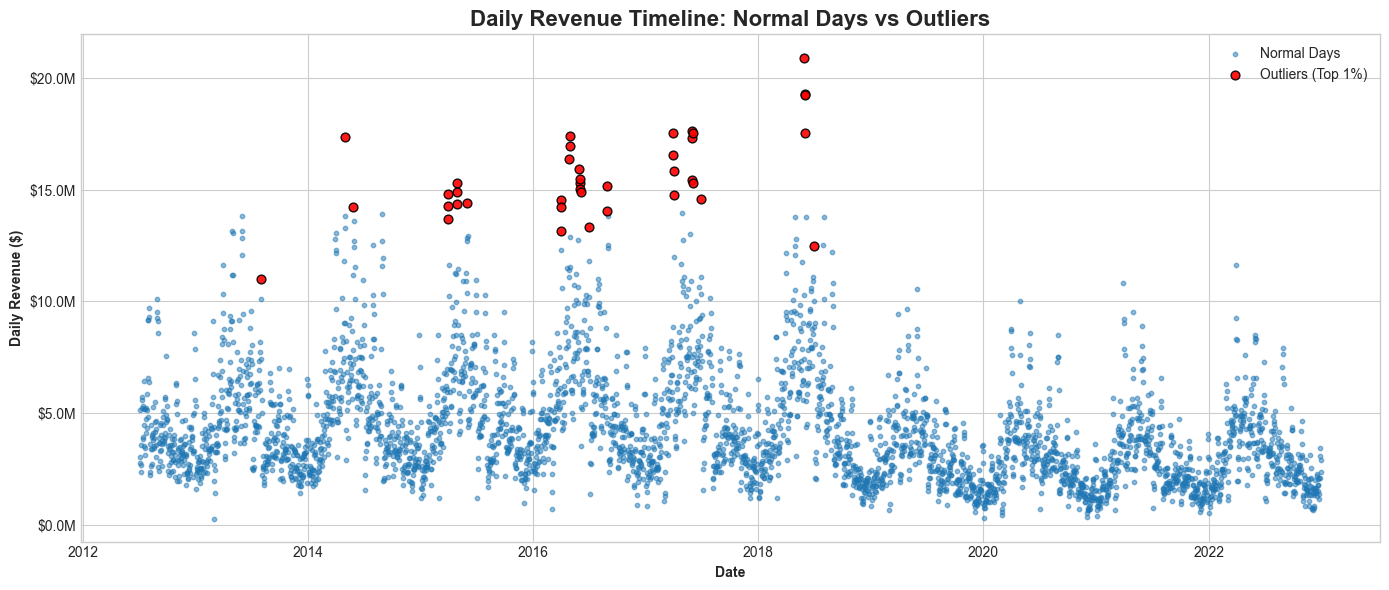

/var/folders/dk/yzyqhttj6jx7wwqy05jnp8ph0000gp/T/ipykernel_57063/1933591747.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outliers_by_month.index, y=outliers_by_month.values, palette='Reds_r')


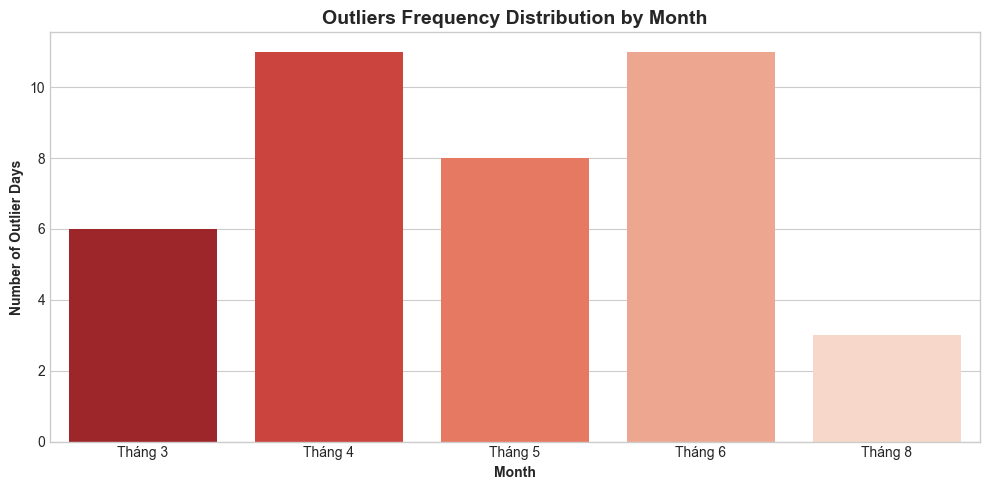

/var/folders/dk/yzyqhttj6jx7wwqy05jnp8ph0000gp/T/ipykernel_57063/1933591747.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Type', y='Gross_Margin_%', palette=['#3498db', '#e74c3c'])


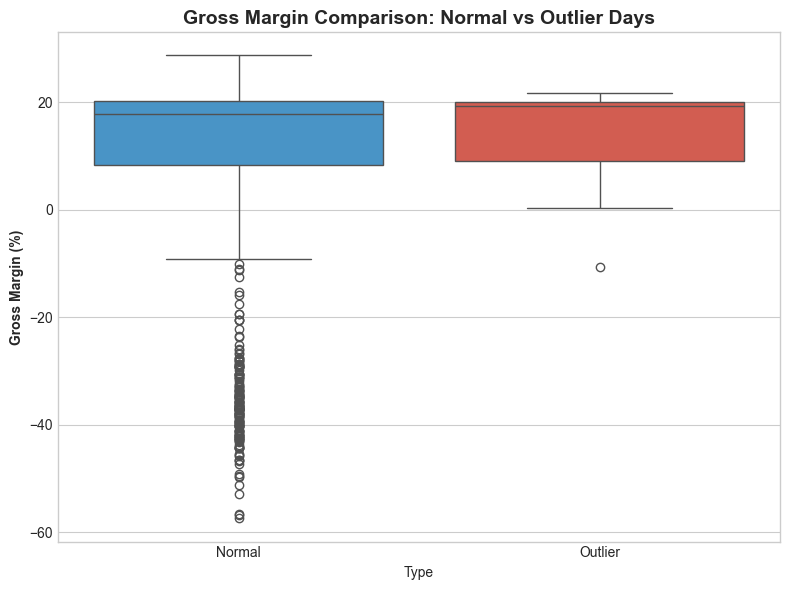

In [37]:
# ============================================================
# CELL 9: Outliers Deep Dive (Phân tích ngoại lai chuyên sâu)
# ============================================================
print("\n=== CELL 9: Outliers Deep Dive ===")
if sales_outliers.height > 0:
    print(f"Tiến hành phân tích sâu {sales_outliers.height} ngày Outliers...")
    
    import pandas as pd
    sales_pd = sales.to_pandas()
    outliers_pd = sales_outliers.to_pandas()
    
    # ----------------------------------------------------
    # CHart 1: Timeline Scatter Plot (Vị trí các Outliers)
    # ----------------------------------------------------
    plt.figure(figsize=(14, 6))
    plt.scatter(sales_pd['Date'], sales_pd['Revenue'], color='tab:blue', alpha=0.5, label='Normal Days', s=10)
    plt.scatter(outliers_pd['Date'], outliers_pd['Revenue'], color='red', alpha=0.9, label='Outliers (Top 1%)', s=40, edgecolors='black')
    
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M'))
    plt.title('Daily Revenue Timeline: Normal Days vs Outliers', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontweight='bold')
    plt.ylabel('Daily Revenue ($)', fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day2_outliers_timeline.png"), bbox_inches="tight")
    plt.show()

    # ----------------------------------------------------
    # Chart 2: Outliers Frequency by Month
    # ----------------------------------------------------
    outliers_pd['Month'] = outliers_pd['Date'].dt.month
    outliers_by_month = outliers_pd['Month'].value_counts().sort_index()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=outliers_by_month.index, y=outliers_by_month.values, palette='Reds_r')
    plt.title('Outliers Frequency Distribution by Month', fontsize=14, fontweight='bold')
    plt.xlabel('Month', fontweight='bold')
    plt.ylabel('Number of Outlier Days', fontweight='bold')
    plt.xticks(ticks=range(len(outliers_by_month)), labels=[f"Tháng {int(m)}" for m in outliers_by_month.index])
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day2_outliers_by_month.png"), bbox_inches="tight")
    plt.show()

    # ----------------------------------------------------
    # Chart 3: Gross Margin Comparison
    # ----------------------------------------------------
    sales_pd['Type'] = 'Normal'
    outliers_pd['Type'] = 'Outlier'
    
    sales_pd['Gross_Margin_%'] = (sales_pd['Revenue'] - sales_pd['COGS']) / sales_pd['Revenue'] * 100
    outliers_pd['Gross_Margin_%'] = (outliers_pd['Revenue'] - outliers_pd['COGS']) / outliers_pd['Revenue'] * 100
    
    combined_df = pd.concat([sales_pd, outliers_pd])
    
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=combined_df, x='Type', y='Gross_Margin_%', palette=['#3498db', '#e74c3c'])
    plt.title('Gross Margin Comparison: Normal vs Outlier Days', fontsize=14, fontweight='bold')
    plt.ylabel('Gross Margin (%)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day2_outliers_margin_compare.png"), bbox_inches="tight")
    plt.show()

# INSIGHT:
# >> "1. Timeline Chart: Cú sốc lớn nhất diễn ra vào chuỗi ngày Hè 2018 và 2017 với mức doanh thu có lúc chạm mốc 20 triệu USD/ngày.\n>> 2. Tháng: 100% Outliers tập trung vào tháng 3, 4, 5, 6 (Đỉnh điểm mùa Xuân Hè).\n>> 3. Gross Margin: Nhóm Outliers có mức biên lợi nhuận cực kỳ chênh lệch (có những ngày biên lợi nhuận bị ép xuống mức rất thấp). Điều này càng củng cố giả thuyết đây là các đợt Mega Sale xả kho giữa năm với mức Discount sâu để đẩy doanh số."
